# Vaccine center experiments

We combine Census county boundaries, county demographics (`uscounties.csv`), and Queen adjacency to compare:

1. **Minimum set cover**: fewest centers so every county is covered by itself or a Queen-neighbor.
2. **Equitable p-median**: minimize population-weighted travel miles with at most `k` centers, with Queen coverage enforced.
3. **P-center (minimax)**: minimize the maximum assigned travel distance with the same `k` cap and Queen coverage.

**Incommensurable objectives:** min-cover minimizes *number of centers*, p-median minimizes *total person-miles*, p-center minimizes *worst-case* distance — you cannot rank solutions by raw IP objectives across models. Instead we report the same **assignment-based metrics** for every solution: total population-weighted distance, max assigned distance, and average miles per person (see comparison tables and k-sweeps below).

County data is parsed before adjacency so `parse_adjacency` can assert adjacency keys match `county_data` JSON.

Story order: setup -> data load -> RI (+ RI k-sweep) -> PA -> TX -> PA k-sweep (commensurable curves) -> comparison.


## Setup


In [9]:
import os
import sys
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = os.path.abspath(".")
PY_SCRIPTS = os.path.join(ROOT, "py_scripts")
sys.path.insert(0, PY_SCRIPTS)

from parse_adjacency import parse_adjacency, load_adjacency
from parse_county_data import parse_county_data, load_county_data
from min_coverage import solve_min_coverage
from equitable_placement import solve_p_median
from p_center import solve_p_center
from helper_functions import (
    assignment_metrics,
    dataframe_assignment,
    plot_centers,
    state_name_to_fips,
)

SHP_PATH = os.path.join(ROOT, "county_data", "cb_2023_us_county_500k", "cb_2023_us_county_500k.shp")
DEMO_PATH = os.path.join(ROOT, "county_data", "uscounties.csv")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")


## Parameters (manual k per state)

Set analyst-controlled `k` values here. For each state run, the notebook validates that:

`k_min_cover <= k <= number_of_counties`


In [10]:
k_ri = 4
k_pa = 43
k_tx = 128

# k-sweep: stride 1 = every k from k_min_cover to n (slow for large states)
k_sweep_stride_pa = 1
k_sweep_stride_tx = 25
run_tx_k_sweep = True


## Data helpers and model runner


In [11]:
def load_state(state_name):
    state_fips = state_name_to_fips(state_name)

    parse_county_data(DEMO_PATH, state_fips)
    cdata = load_county_data(state_fips)

    parse_adjacency(state_fips)
    adj = load_adjacency(state_fips)

    shp = gpd.read_file(SHP_PATH)
    state_shp = shp[shp["STATEFP"] == state_fips].copy()

    return adj, cdata, state_shp


def run_state_optimization(state_name, k):
    adj, cdata, state_shp = load_state(state_name)
    n = len(cdata)

    centers_a, obj_a, time_a, assigned_a = solve_min_coverage(adj, cdata)
    k_min_cover = int(round(obj_a))
    k_max = n

    print(f"[{state_name}] k bounds: k_min_cover={k_min_cover}, k_max={k_max}, k_used={k}")
    if not (k_min_cover <= k <= k_max):
        raise ValueError(
            f"[{state_name}] invalid k={k}; must satisfy {k_min_cover} <= k <= {k_max}"
        )

    centers_b, obj_b, time_b, assigned_b = solve_p_median(cdata, k, adj)
    centers_pc, obj_pc, time_pc, assigned_pc = solve_p_center(cdata, k, adj)

    return {
        "state_name": state_name,
        "adj": adj,
        "cdata": cdata,
        "state_shp": state_shp,
        "n": n,
        "k": k,
        "k_min_cover": k_min_cover,
        "k_max": k_max,
        "centers_a": centers_a,
        "obj_a": obj_a,
        "time_a": time_a,
        "assigned_a": assigned_a,
        "df_a": dataframe_assignment(centers_a, assigned_a, cdata),
        "centers_b": centers_b,
        "obj_b": obj_b,
        "time_b": time_b,
        "assigned_b": assigned_b,
        "df_b": dataframe_assignment(centers_b, assigned_b, cdata),
        "centers_pc": centers_pc,
        "obj_pc": obj_pc,
        "time_pc": time_pc,
        "assigned_pc": assigned_pc,
        "df_pc": dataframe_assignment(centers_pc, assigned_pc, cdata),
    }


def display_state_tables_and_maps(res):
    shp, cd = res["state_shp"], res["cdata"]
    k = res["k"]
    name = res["state_name"]

    print(f"{name} min coverage: centers={len(res['centers_a'])}, objective={res['obj_a']}, time={res['time_a']:.4f}s")
    display(res["df_a"])
    plot_centers(shp, cd, res["centers_a"], "min coverage")

    print(f"{name} p-median (k={k}): objective={res['obj_b']:,.2f} person-miles, time={res['time_b']:.4f}s")
    display(res["df_b"])
    plot_centers(shp, cd, res["centers_b"], f"k={k} p-median")

    print(f"{name} p-center (k={k}): max distance={res['obj_pc']:.4f} miles, time={res['time_pc']:.4f}s")
    display(res["df_pc"])
    plot_centers(shp, cd, res["centers_pc"], f"k={k} p-center")


def sweep_p_median_p_center_metrics(cdata, adj, k_min, k_max, stride=1):
    """For each k, solve p-median and p-center; return commensurable metrics (not raw IP objectives)."""
    rows = []
    k = k_min
    while k <= k_max:
        centers_pm, _, _, assigned_pm = solve_p_median(cdata, k, adj)
        centers_pc, _, _, assigned_pc = solve_p_center(cdata, k, adj)
        m_pm = assignment_metrics(cdata, assigned_pm)
        m_pc = assignment_metrics(cdata, assigned_pc)
        rows.append(
            {
                "k": k,
                "pm_total_person_miles": m_pm["total_person_miles"],
                "pm_max_miles": m_pm["max_miles"],
                "pm_avg_miles": m_pm["avg_miles_per_person"],
                "pc_total_person_miles": m_pc["total_person_miles"],
                "pc_max_miles": m_pc["max_miles"],
                "pc_avg_miles": m_pc["avg_miles_per_person"],
                "centers_match": set(centers_pm) == set(centers_pc),
            }
        )
        k += stride
    return pd.DataFrame(rows)


def plot_sweep_metrics(df_sweep, title_prefix, mc_ref=None):
    """Three panels (p-median vs p-center); optional dashed lines = min-cover baseline."""
    ks = df_sweep["k"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].plot(ks, df_sweep["pm_total_person_miles"], "o-", ms=3, label="p-median")
    axes[0].plot(ks, df_sweep["pc_total_person_miles"], "s-", ms=3, label="p-center")
    if mc_ref is not None:
        axes[0].axhline(mc_ref["total_person_miles"], color="gray", ls="--", lw=1, label="min-cover")
    axes[0].set_ylabel("Person-miles")
    axes[0].set_xlabel("k")
    axes[0].set_title(f"{title_prefix}: total pop-weighted distance")
    axes[0].legend(fontsize=7)
    axes[0].grid(alpha=0.3)

    axes[1].plot(ks, df_sweep["pm_max_miles"], "o-", ms=3, label="p-median")
    axes[1].plot(ks, df_sweep["pc_max_miles"], "s-", ms=3, label="p-center")
    if mc_ref is not None:
        axes[1].axhline(mc_ref["max_miles"], color="gray", ls="--", lw=1, label="min-cover")
    axes[1].set_ylabel("Miles")
    axes[1].set_xlabel("k")
    axes[1].set_title(f"{title_prefix}: max assigned distance")
    axes[1].legend(fontsize=7)
    axes[1].grid(alpha=0.3)

    axes[2].plot(ks, df_sweep["pm_avg_miles"], "o-", ms=3, label="p-median")
    axes[2].plot(ks, df_sweep["pc_avg_miles"], "s-", ms=3, label="p-center")
    if mc_ref is not None:
        axes[2].axhline(mc_ref["avg_miles_per_person"], color="gray", ls="--", lw=1, label="min-cover")
    axes[2].set_ylabel("Miles / person")
    axes[2].set_xlabel("k")
    axes[2].set_title(f"{title_prefix}: avg miles per person")
    axes[2].legend(fontsize=7)
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def commensurable_comparison_rows(res):
    """One row per model at this state's chosen k (min-cover uses its own center count)."""
    state = res["state_name"]
    cdata = res["cdata"]
    k = res["k"]
    rows = []

    m = assignment_metrics(cdata, res["assigned_a"])
    rows.append(
        {
            "State": state,
            "Model": "min_coverage",
            "k": len(res["centers_a"]),
            "native_label": "centers (IP objective)",
            "native_value": float(res["obj_a"]),
            "total_person_miles": m["total_person_miles"],
            "max_miles": m["max_miles"],
            "avg_miles_per_person": m["avg_miles_per_person"],
        }
    )
    m = assignment_metrics(cdata, res["assigned_b"])
    rows.append(
        {
            "State": state,
            "Model": "p_median",
            "k": k,
            "native_label": "person-miles (IP objective)",
            "native_value": float(res["obj_b"]),
            "total_person_miles": m["total_person_miles"],
            "max_miles": m["max_miles"],
            "avg_miles_per_person": m["avg_miles_per_person"],
        }
    )
    m = assignment_metrics(cdata, res["assigned_pc"])
    rows.append(
        {
            "State": state,
            "Model": "p_center",
            "k": k,
            "native_label": "max miles (IP objective)",
            "native_value": float(res["obj_pc"]),
            "total_person_miles": m["total_person_miles"],
            "max_miles": m["max_miles"],
            "avg_miles_per_person": m["avg_miles_per_person"],
        }
    )
    return rows


## Rhode Island


[Rhode Island] k bounds: k_min_cover=3, k_max=5, k_used=4
Rhode Island min coverage: centers=3, objective=3.0, time=0.0009s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,44001,Bristol County,50490,False,44007,Providence County,18.624769,9.403646e+05
1,44003,Kent County,171456,True,44003,Kent County,0.000000,0.000000e+00
2,44005,Newport County,84657,True,44005,Newport County,0.000000,0.000000e+00
3,44007,Providence County,664854,True,44007,Providence County,0.000000,0.000000e+00
4,44009,Washington County,130344,False,44003,Kent County,14.073710,1.834424e+06


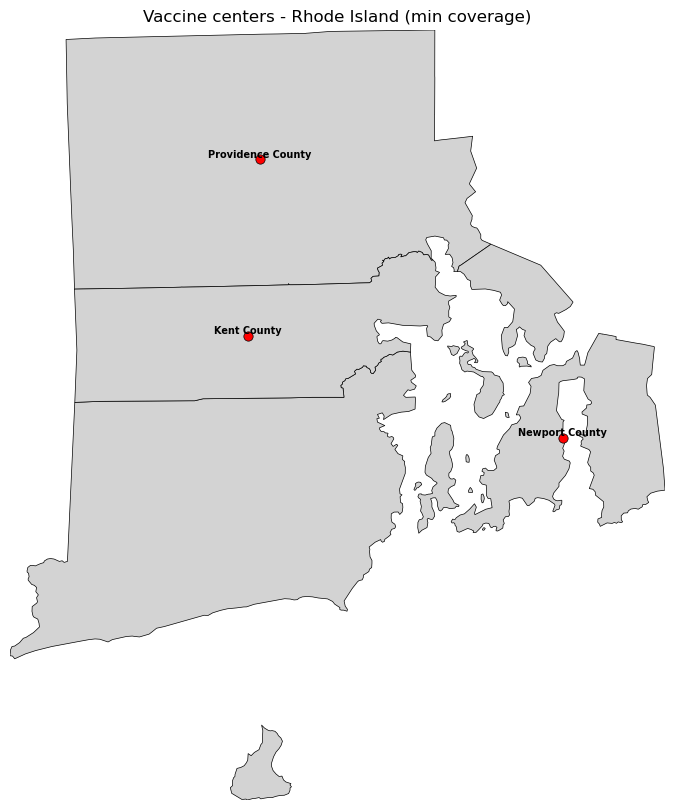

Rhode Island p-median (k=4): objective=573,553.82 person-miles, time=0.0017s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,44001,Bristol County,50490,False,44005,Newport County,11.359751,573553.820873
1,44003,Kent County,171456,True,44003,Kent County,0.000000,0.000000
2,44005,Newport County,84657,True,44005,Newport County,0.000000,0.000000
3,44007,Providence County,664854,True,44007,Providence County,0.000000,0.000000
4,44009,Washington County,130344,True,44009,Washington County,0.000000,0.000000


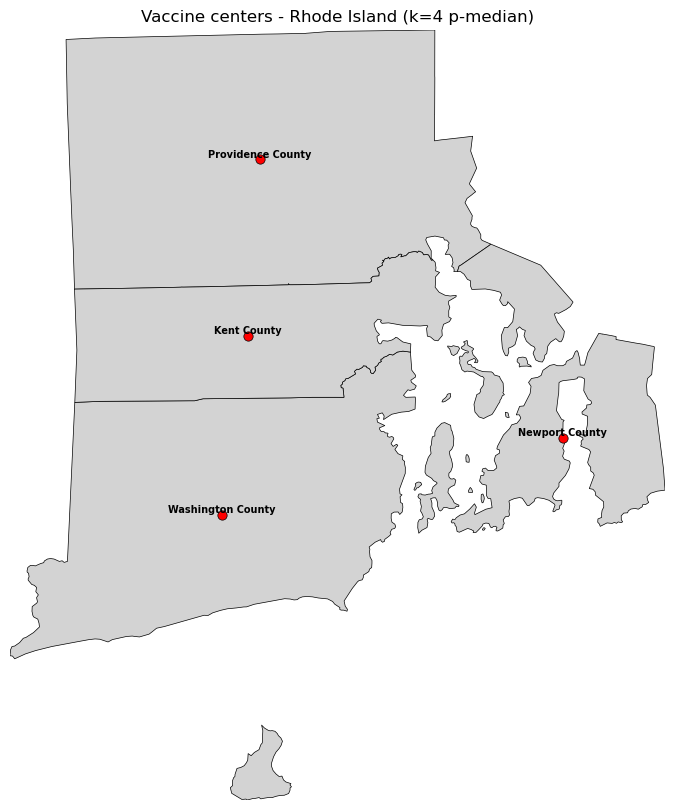

Rhode Island p-center (k=4): max distance=11.3598 miles, time=0.0022s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,44001,Bristol County,50490,False,44005,Newport County,11.359751,573553.820873
1,44003,Kent County,171456,True,44003,Kent County,0.000000,0.000000
2,44005,Newport County,84657,True,44005,Newport County,0.000000,0.000000
3,44007,Providence County,664854,True,44007,Providence County,0.000000,0.000000
4,44009,Washington County,130344,True,44009,Washington County,0.000000,0.000000


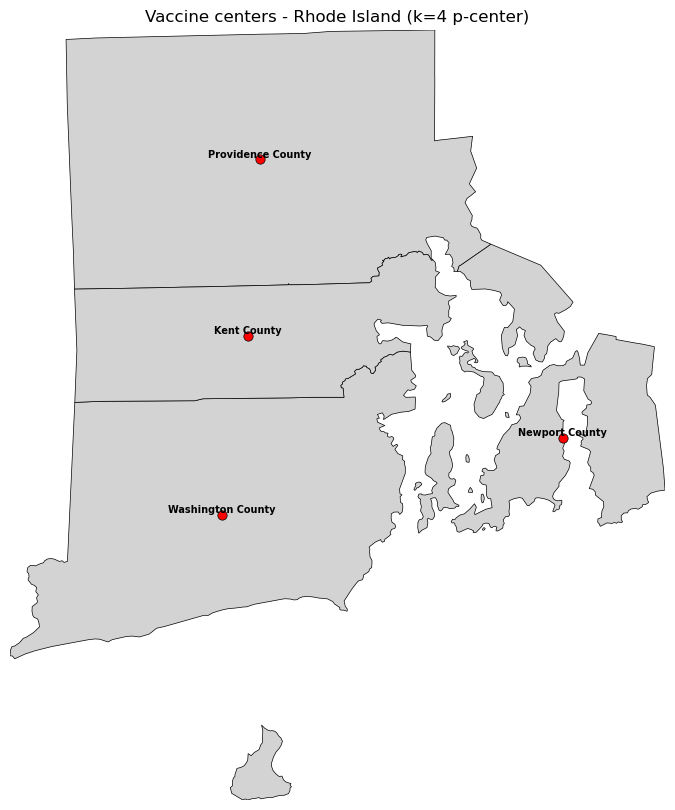

,k,pm_total_person_miles,pm_max_miles,pm_avg_miles,pc_total_person_miles,pc_max_miles,pc_avg_miles,centers_match
0,3,2.407977e+06,14.073710,2.185492,2.944535e+06,13.828513,2.672475,False
1,4,5.735538e+05,11.359751,0.520560,5.735538e+05,11.359751,0.520560,True
2,5,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,True


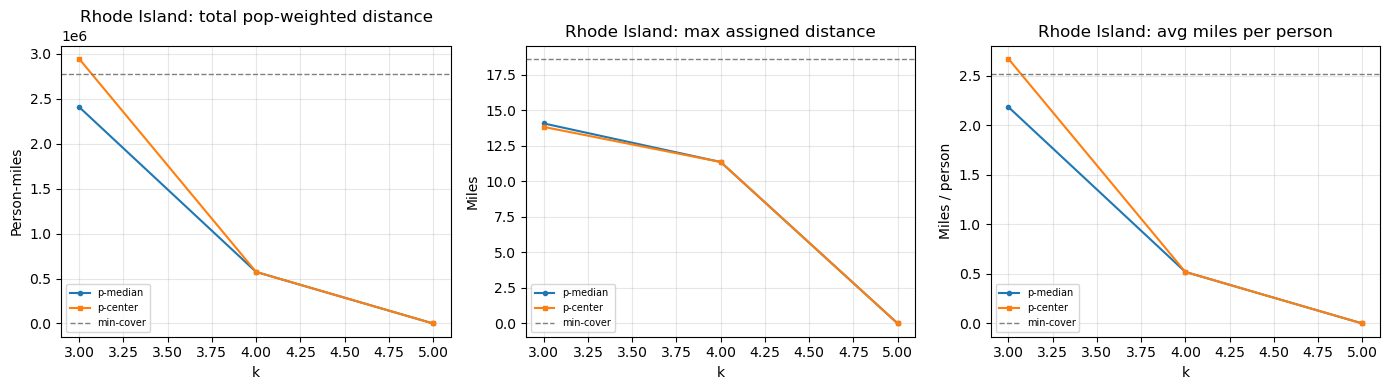

In [12]:
res_ri = run_state_optimization("Rhode Island", k_ri)
display_state_tables_and_maps(res_ri)

# Full k sweep (small state): commensurable metrics + min-cover reference lines
df_ri_sweep = sweep_p_median_p_center_metrics(
    res_ri["cdata"], res_ri["adj"], res_ri["k_min_cover"], res_ri["n"], stride=1
)
mc_ref_ri = assignment_metrics(res_ri["cdata"], res_ri["assigned_a"])
display(df_ri_sweep)
plot_sweep_metrics(df_ri_sweep, "Rhode Island", mc_ref=mc_ref_ri)


## Pennsylvania


[Pennsylvania] k bounds: k_min_cover=12, k_max=67, k_used=43
Pennsylvania min coverage: centers=12, objective=12.0, time=0.0015s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,42001,Adams County,106115,False,42133,York County,26.263421,2.786943e+06
1,42003,Allegheny County,1238177,False,42019,Butler County,30.828124,3.817067e+07
2,42005,Armstrong County,64622,False,42019,Butler County,24.441434,1.579454e+06
3,42007,Beaver County,166324,False,42019,Butler County,27.784117,4.621165e+06
4,42009,Bedford County,47513,False,42061,Huntingdon County,39.059282,1.855824e+06
5,42011,Berks County,433015,False,42107,Schuylkill County,25.136089,1.088430e+07
6,42013,Blair County,121277,False,42061,Huntingdon County,19.804868,2.401875e+06
7,42015,Bradford County,59858,False,42131,Wyoming County,31.818369,1.904584e+06
8,42017,Bucks County,647461,False,42091,Montgomery County,16.258719,1.052689e+07
9,42019,Butler County,197254,True,42019,Butler County,0.000000,0.000000e+00


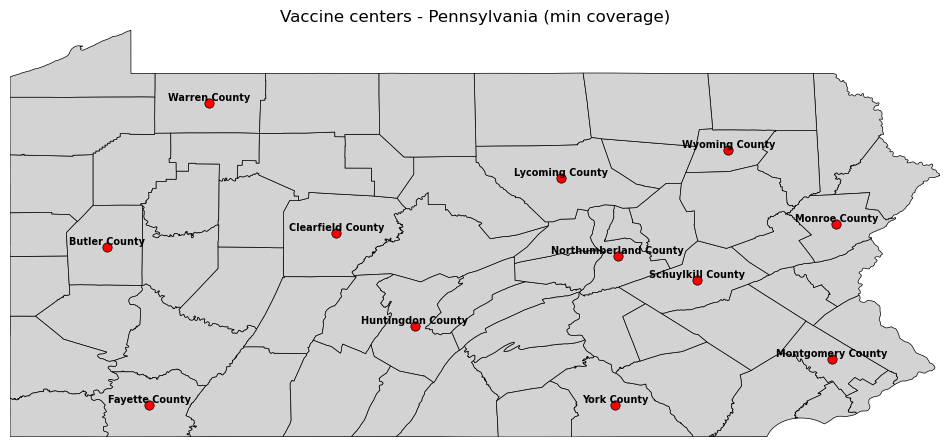

Pennsylvania p-median (k=43): objective=19,247,030.33 person-miles, time=0.0376s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,42001,Adams County,106115,True,42001,Adams County,0.000000,0.000000e+00
1,42003,Allegheny County,1238177,True,42003,Allegheny County,0.000000,0.000000e+00
2,42005,Armstrong County,64622,True,42005,Armstrong County,0.000000,0.000000e+00
3,42007,Beaver County,166324,True,42007,Beaver County,0.000000,0.000000e+00
4,42009,Bedford County,47513,False,42111,Somerset County,28.576659,1.357763e+06
5,42011,Berks County,433015,True,42011,Berks County,0.000000,0.000000e+00
6,42013,Blair County,121277,True,42013,Blair County,0.000000,0.000000e+00
7,42015,Bradford County,59858,True,42015,Bradford County,0.000000,0.000000e+00
8,42017,Bucks County,647461,True,42017,Bucks County,0.000000,0.000000e+00
9,42019,Butler County,197254,True,42019,Butler County,0.000000,0.000000e+00


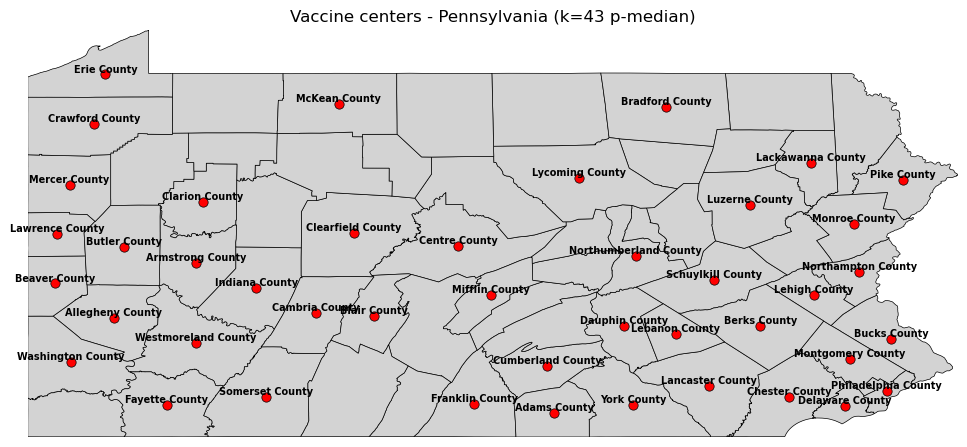

Pennsylvania p-center (k=43): max distance=22.1673 miles, time=0.2228s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,42001,Adams County,106115,False,42041,Cumberland County,20.338751,2.158247e+06
1,42003,Allegheny County,1238177,True,42003,Allegheny County,0.000000,0.000000e+00
2,42005,Armstrong County,64622,True,42005,Armstrong County,0.000000,0.000000e+00
3,42007,Beaver County,166324,False,42073,Lawrence County,21.356598,3.552115e+06
4,42009,Bedford County,47513,False,42057,Fulton County,20.766095,9.866595e+05
5,42011,Berks County,433015,False,42077,Lehigh County,22.167321,9.598782e+06
6,42013,Blair County,121277,True,42013,Blair County,0.000000,0.000000e+00
7,42015,Bradford County,59858,True,42015,Bradford County,0.000000,0.000000e+00
8,42017,Bucks County,647461,False,42091,Montgomery County,16.258719,1.052689e+07
9,42019,Butler County,197254,True,42019,Butler County,0.000000,0.000000e+00


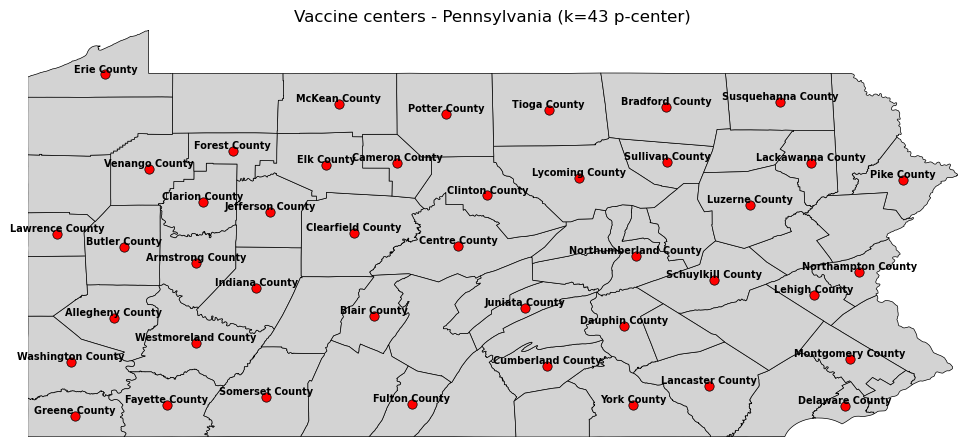

PA times: min-cover=0.0015s, p-median=0.0376s, p-center=0.2228s


In [13]:
res_pa = run_state_optimization("Pennsylvania", k_pa)
display_state_tables_and_maps(res_pa)
print(f"PA times: min-cover={res_pa['time_a']:.4f}s, p-median={res_pa['time_b']:.4f}s, p-center={res_pa['time_pc']:.4f}s")


## Texas


[Texas] k bounds: k_min_cover=41, k_max=254, k_used=128
Texas min coverage: centers=41, objective=41.0, time=0.0969s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,48001,Anderson County,58439,False,48225,Houston County,36.818184,2.151618e+06
1,48003,Andrews County,18610,False,48317,Martin County,40.084712,7.459765e+05
2,48005,Angelina County,87275,False,48225,Houston County,48.071317,4.195424e+06
3,48007,Aransas County,24876,False,48355,Nueces County,46.870877,1.165960e+06
4,48009,Archer County,8867,False,48023,Baylor County,30.253963,2.682619e+05
5,48011,Armstrong County,1822,True,48011,Armstrong County,0.000000,0.000000e+00
6,48013,Atascosa County,51008,False,48255,Karnes County,40.403342,2.060894e+06
7,48015,Austin County,31170,False,48477,Washington County,23.840412,7.431056e+05
8,48017,Bailey County,6913,False,48369,Parmer County,31.991735,2.211589e+05
9,48019,Bandera County,22021,False,48463,Uvalde County,41.075896,9.045323e+05


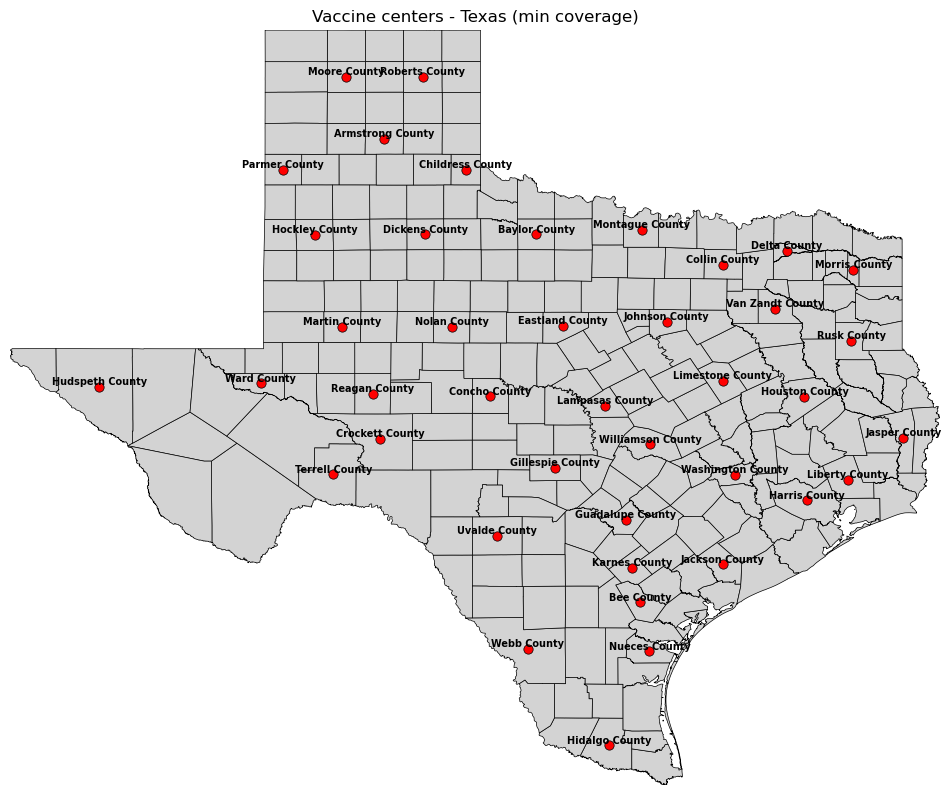

Texas p-median (k=128): objective=28,823,698.74 person-miles, time=0.8301s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,48001,Anderson County,58439,True,48001,Anderson County,0.000000,0.000000
1,48003,Andrews County,18610,False,48165,Gaines County,30.111264,560370.627253
2,48005,Angelina County,87275,True,48005,Angelina County,0.000000,0.000000
3,48007,Aransas County,24876,True,48007,Aransas County,0.000000,0.000000
4,48009,Archer County,8867,False,48485,Wichita County,25.767090,228476.791184
5,48011,Armstrong County,1822,False,48381,Randall County,30.553238,55668.000302
6,48013,Atascosa County,51008,True,48013,Atascosa County,0.000000,0.000000
7,48015,Austin County,31170,True,48015,Austin County,0.000000,0.000000
8,48017,Bailey County,6913,False,48219,Hockley County,42.364171,292863.515383
9,48019,Bandera County,22021,False,48265,Kerr County,22.586812,497384.183610


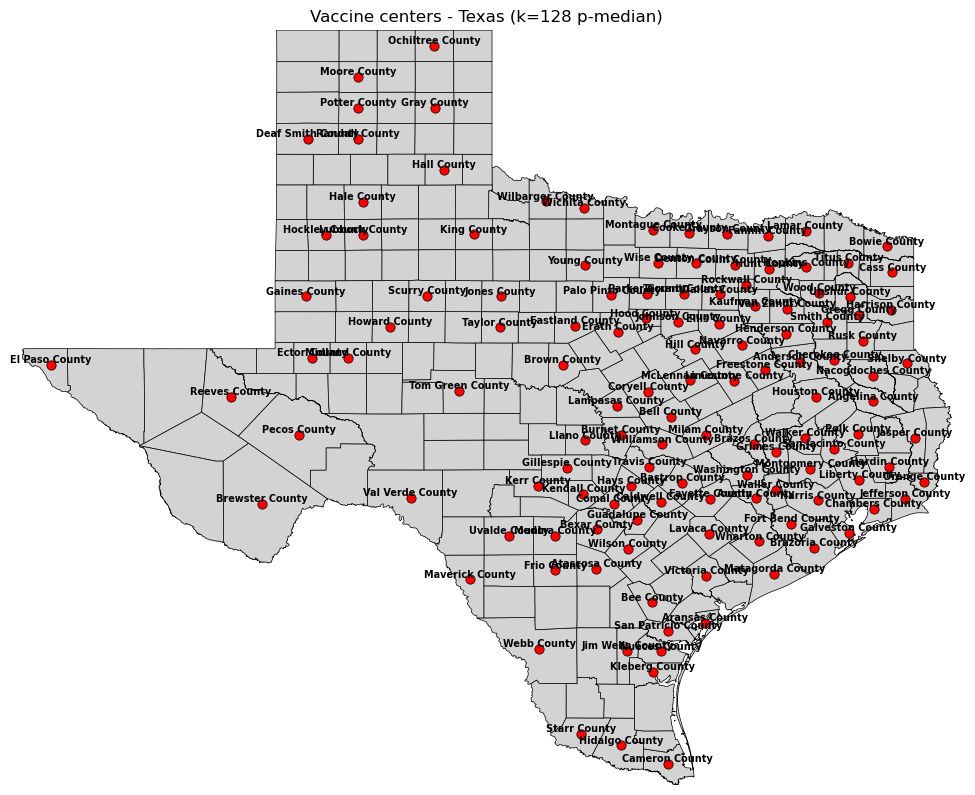

Texas p-center (k=128): max distance=30.1159 miles, time=3.3128s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,48001,Anderson County,58439,True,48001,Anderson County,0.000000,0.000000e+00
1,48003,Andrews County,18610,False,48165,Gaines County,30.111264,5.603706e+05
2,48005,Angelina County,87275,True,48005,Angelina County,0.000000,0.000000e+00
3,48007,Aransas County,24876,False,48391,Refugio County,17.343276,4.314313e+05
4,48009,Archer County,8867,True,48009,Archer County,0.000000,0.000000e+00
5,48011,Armstrong County,1822,True,48011,Armstrong County,0.000000,0.000000e+00
6,48013,Atascosa County,51008,True,48013,Atascosa County,0.000000,0.000000e+00
7,48015,Austin County,31170,True,48015,Austin County,0.000000,0.000000e+00
8,48017,Bailey County,6913,False,48279,Lamb County,27.369628,1.892062e+05
9,48019,Bandera County,22021,True,48019,Bandera County,0.000000,0.000000e+00


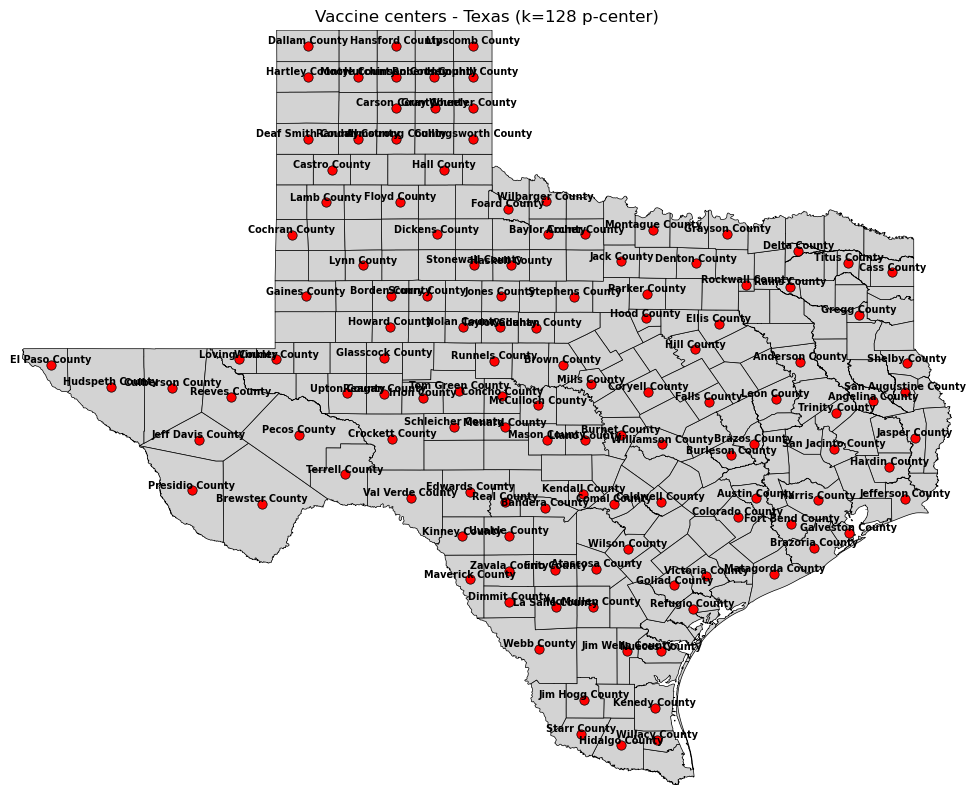

TX times: min-cover=0.0969s, p-median=0.8301s, p-center=3.3128s


,k,pm_total_person_miles,pm_max_miles,pm_avg_miles,pc_total_person_miles,pc_max_miles,pc_avg_miles,centers_match
0,41,5.687093e+08,81.896527,18.838655,9.624097e+08,60.628627,31.880092,False
1,66,1.200784e+08,68.524361,3.977632,8.439691e+08,37.316000,27.956713,False
2,91,6.298660e+07,68.524361,2.086449,5.987148e+08,31.652078,19.832596,False
3,116,3.694910e+07,60.628627,1.223949,3.903489e+08,30.253963,12.930416,False
4,141,2.161618e+07,60.628627,0.716042,3.972865e+08,30.016832,13.160227,False
5,166,1.169465e+07,59.425598,0.387388,3.422629e+08,28.856293,11.337555,False
6,191,5.834411e+06,54.399313,0.193266,2.032673e+08,27.568275,6.733286,False
7,216,2.187031e+06,52.442304,0.072446,1.546022e+08,24.853961,5.121240,False
8,241,3.003219e+05,31.816574,0.009948,8.209468e+06,20.269711,0.271941,False


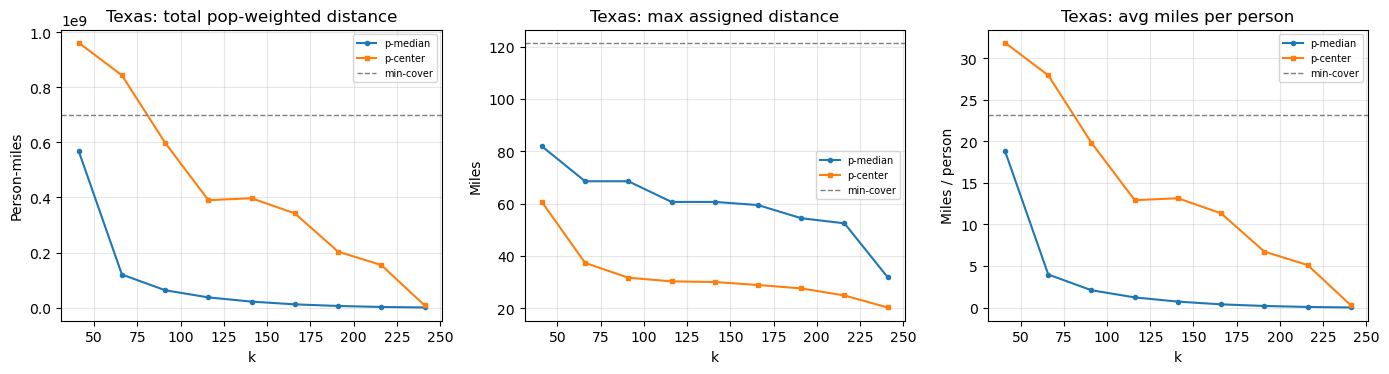

In [14]:
res_tx = run_state_optimization("Texas", k_tx)
display_state_tables_and_maps(res_tx)
print(f"TX times: min-cover={res_tx['time_a']:.4f}s, p-median={res_tx['time_b']:.4f}s, p-center={res_tx['time_pc']:.4f}s")

if run_tx_k_sweep:
    df_tx_sweep = sweep_p_median_p_center_metrics(
        res_tx["cdata"],
        res_tx["adj"],
        res_tx["k_min_cover"],
        res_tx["n"],
        stride=k_sweep_stride_tx,
    )
    mc_ref_tx = assignment_metrics(res_tx["cdata"], res_tx["assigned_a"])
    display(df_tx_sweep.head(20))
    plot_sweep_metrics(df_tx_sweep, "Texas", mc_ref=mc_ref_tx)


## Pennsylvania k sweep (commensurable metrics)

For each `k` from `k_min_cover` through `n`, run p-median and p-center and record **assignment metrics** (total person-miles, max distance, avg miles per person)—not raw IP objectives on the same axis. Gray dashed lines = min-cover baseline at its optimal center count.

Use `k_sweep_stride_pa` > 1 to skip k values if the run is too slow. At `k = n` all three metrics go to zero (each county serves itself). Watch for **diminishing returns** (sharp drop then flatten), **convergence** toward zero, and **crossovers** (`centers_match` in the table).


Pennsylvania k-sweep: stride=1, ~56 values (k from 12 to 67)


,k,pm_total_person_miles,pm_max_miles,pm_avg_miles,pc_total_person_miles,pc_max_miles,pc_avg_miles,centers_match
0,12,2.557532e+08,51.162018,19.645158,3.038222e+08,43.820422,23.337477,False
1,13,2.180699e+08,51.162018,16.750588,2.860840e+08,38.094608,21.974958,False
2,14,1.935372e+08,44.763792,14.866160,2.724893e+08,36.314693,20.930703,False
3,15,1.718582e+08,44.763792,13.200936,2.762303e+08,33.636015,21.218062,False
4,16,1.564937e+08,44.763792,12.020742,2.650068e+08,33.280868,20.355949,False
5,17,1.422551e+08,44.763792,10.927030,2.563096e+08,32.910570,19.687893,False
6,18,1.304627e+08,44.763792,10.021221,2.339471e+08,30.909029,17.970166,False
7,19,1.199358e+08,44.763792,9.212620,2.470896e+08,30.746258,18.979678,False
8,20,1.100168e+08,44.763792,8.450712,2.355880e+08,29.494697,18.096209,False
9,21,9.979649e+07,44.763792,7.665662,2.326512e+08,28.638342,17.870623,False


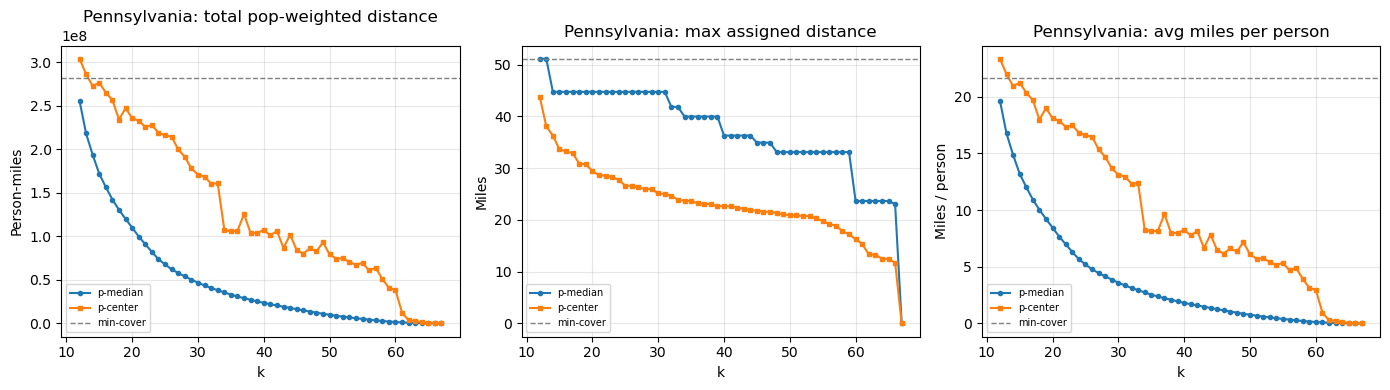

In [15]:
k0_pa = res_pa["k_min_cover"]
kmax_pa = res_pa["n"]
n_k = len(range(k0_pa, kmax_pa + 1, k_sweep_stride_pa))
print(f"Pennsylvania k-sweep: stride={k_sweep_stride_pa}, ~{n_k} values (k from {k0_pa} to {kmax_pa})")

df_pa_sweep = sweep_p_median_p_center_metrics(
    res_pa["cdata"], res_pa["adj"], k0_pa, kmax_pa, stride=k_sweep_stride_pa
)
mc_ref_pa = assignment_metrics(res_pa["cdata"], res_pa["assigned_a"])
display(df_pa_sweep)
plot_sweep_metrics(df_pa_sweep, "Pennsylvania", mc_ref=mc_ref_pa)


## RI / PA / TX comparison (commensurable metrics)

Native objectives are listed per model for reference; **total_person_miles**, **max_miles**, and **avg_miles_per_person** are comparable across all three.


In [16]:
rows = []
for res in (res_ri, res_pa, res_tx):
    rows.extend(commensurable_comparison_rows(res))

df_cmp = pd.DataFrame(rows)
display(df_cmp)


,State,Model,k,native_label,native_value,total_person_miles,max_miles,avg_miles_per_person
0,Rhode Island,min_coverage,3,centers (IP objective),3.000000e+00,2.774788e+06,18.624769,2.518411
1,Rhode Island,p_median,4,person-miles (IP objective),5.735538e+05,5.735538e+05,11.359751,0.520560
2,Rhode Island,p_center,4,max miles (IP objective),1.135975e+01,5.735538e+05,11.359751,0.520560
3,Pennsylvania,min_coverage,12,centers (IP objective),1.200000e+01,2.818627e+08,51.162018,21.650702
4,Pennsylvania,p_median,43,person-miles (IP objective),1.924703e+07,1.924703e+07,36.314693,1.478421
5,Pennsylvania,p_center,43,max miles (IP objective),2.216732e+01,8.656599e+07,22.167321,6.649388
6,Texas,min_coverage,41,centers (IP objective),4.100000e+01,7.000003e+08,121.482973,23.187707
7,Texas,p_median,128,person-miles (IP objective),2.882370e+07,2.882370e+07,60.628627,0.954793
8,Texas,p_center,128,max miles (IP objective),3.011587e+01,4.407903e+08,30.115874,14.601302
